In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("Flight_Delay.parquet")
df.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,OriginCityName,DestCityName,CRSDepTime,DepTime,DepDelay,...,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1,2018,1,15,2018-01-15,UA,"Newark, NJ","Charleston, SC",1845,1928.0,43.0,...,143.0,141.0,102.0,628.0,3,41.0,0.0,0.0,0.0,0.0
2,2018,1,16,2018-01-16,UA,"Newark, NJ","Charleston, SC",1835,1956.0,81.0,...,143.0,131.0,108.0,628.0,3,67.0,0.0,0.0,0.0,2.0
3,2018,1,17,2018-01-17,UA,"Newark, NJ","Charleston, SC",1835,1836.0,1.0,...,143.0,138.0,113.0,628.0,3,0.0,0.0,0.0,0.0,0.0
4,2018,1,18,2018-01-18,UA,"Newark, NJ","Charleston, SC",1845,1844.0,-1.0,...,143.0,134.0,92.0,628.0,3,0.0,0.0,0.0,0.0,0.0
6,2018,1,20,2018-01-20,UA,"Newark, NJ","Charleston, SC",1835,1829.0,-6.0,...,143.0,117.0,89.0,628.0,3,0.0,0.0,0.0,0.0,0.0


In [2]:
print("Shape:", df.shape)

display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
}).sort_values("missing_pct", ascending=False))

Shape: (30132672, 29)


,column,dtype,missing_count,missing_pct
0,Year,int64,0,0.0
15,CRSArrTime,int64,0,0.0
27,SecurityDelay,float64,0,0.0
26,NASDelay,float64,0,0.0
25,WeatherDelay,float64,0,0.0
24,CarrierDelay,float64,0,0.0
23,DistanceGroup,int64,0,0.0
22,Distance,float64,0,0.0
21,AirTime,float64,0,0.0
20,ActualElapsedTime,float64,0,0.0


In [3]:
# convert FlightDate to datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# extract useful time features
df["year"] = df["FlightDate"].dt.year
df["month"] = df["FlightDate"].dt.month
df["day"] = df["FlightDate"].dt.day
df["day_of_week"] = df["FlightDate"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df[["FlightDate","year","month","day","day_of_week","is_weekend"]].head()

,FlightDate,year,month,day,day_of_week,is_weekend
1,2018-01-15,2018,1,15,0,0
2,2018-01-16,2018,1,16,1,0
3,2018-01-17,2018,1,17,2,0
4,2018-01-18,2018,1,18,3,0
6,2018-01-20,2018,1,20,5,1


In [4]:
def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    return (x // 100) * 60 + (x % 100)

time_cols = [
    "CRSDepTime",
    "DepTime",
    "CRSArrTime",
    "ArrTime",
    "WheelsOff",
    "WheelsOn"
]

for col in time_cols:
    df[col + "_min"] = df[col].apply(hhmm_to_minutes)

df[[c for c in df.columns if "_min" in c]].head()

,CRSDepTime_min,DepTime_min,CRSArrTime_min,ArrTime_min,WheelsOff_min,WheelsOn_min
1,1125,1168,1268,1309,1203,1305
2,1115,1196,1258,1327,1214,1322
3,1115,1116,1258,1254,1135,1248
4,1125,1124,1268,1258,1160,1252
6,1115,1109,1258,1226,1131,1220


In [5]:
# departure and arrival hour
df["dep_hour"] = df["CRSDepTime_min"] // 60
df["arr_hour"] = df["CRSArrTime_min"] // 60

# time-of-day buckets
df["dep_period"] = pd.cut(
    df["dep_hour"],
    bins=[0,6,12,18,24],
    labels=["night","morning","afternoon","evening"],
    right=False
)

# rush hour indicator (common congestion windows)
df["rush_hour"] = df["dep_hour"].isin([6,7,8,16,17,18]).astype(int)

df[["CRSDepTime_min","dep_hour","dep_period","rush_hour"]].head()

,CRSDepTime_min,dep_hour,dep_period,rush_hour
1,1125,18,evening,1
2,1115,18,evening,1
3,1115,18,evening,1
4,1125,18,evening,1
6,1115,18,evening,1


In [6]:
# route feature
df["route"] = df["OriginCityName"] + " -> " + df["DestCityName"]

# simple airline encoding for modeling
df["airline_code"] = df["Marketing_Airline_Network"].astype("category").cat.codes

df[[
    "Marketing_Airline_Network",
    "OriginCityName",
    "DestCityName",
    "route",
    "airline_code"
]].head()

,Marketing_Airline_Network,OriginCityName,DestCityName,route,airline_code
1,UA,"Newark, NJ","Charleston, SC","Newark, NJ -> Charleston, SC",8
2,UA,"Newark, NJ","Charleston, SC","Newark, NJ -> Charleston, SC",8
3,UA,"Newark, NJ","Charleston, SC","Newark, NJ -> Charleston, SC",8
4,UA,"Newark, NJ","Charleston, SC","Newark, NJ -> Charleston, SC",8
6,UA,"Newark, NJ","Charleston, SC","Newark, NJ -> Charleston, SC",8


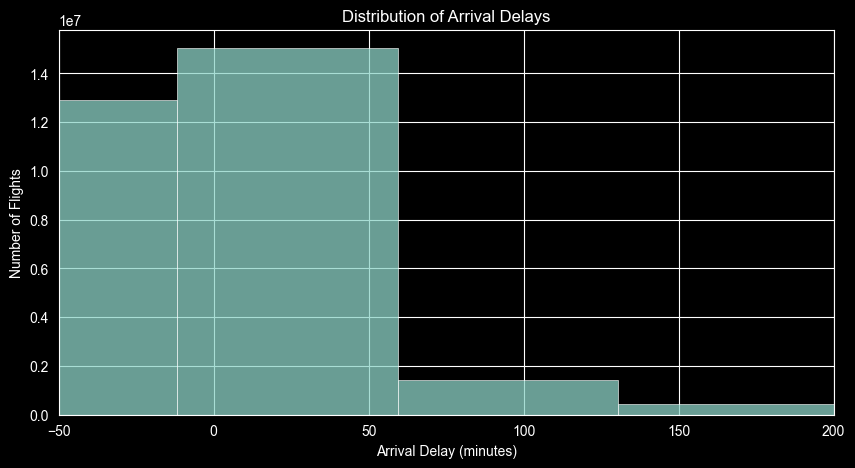

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["ArrDelay"], bins=120)

plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()

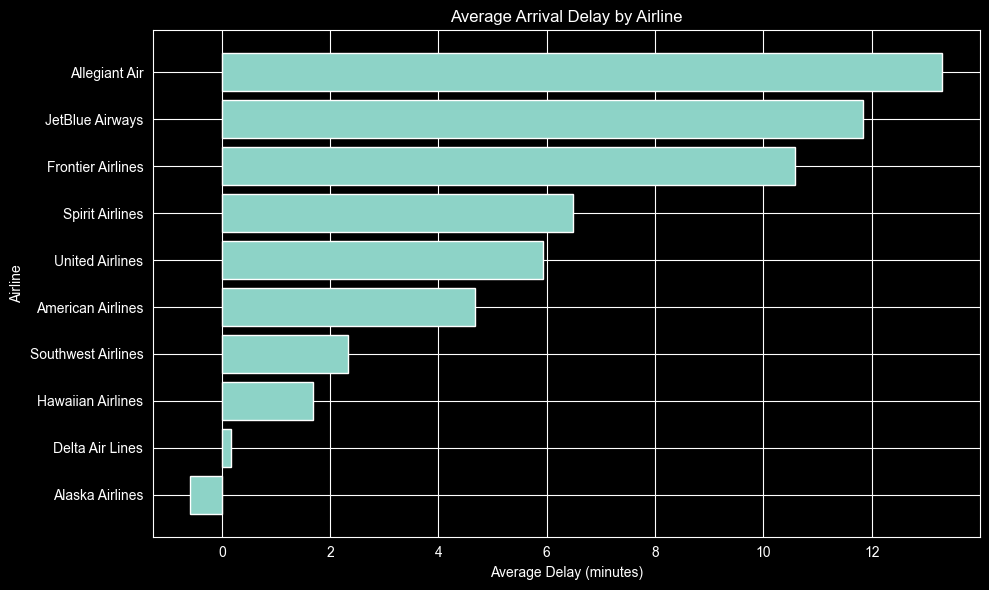

In [10]:
airline_map = {
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue Airways",
    "DL": "Delta Air Lines",
    "F9": "Frontier Airlines",
    "G4": "Allegiant Air",
    "HA": "Hawaiian Airlines",
    "NK": "Spirit Airlines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines"
}

df["AirlineName"] = df["Marketing_Airline_Network"].map(airline_map)

df[["Marketing_Airline_Network", "AirlineName"]].drop_duplicates().sort_values("Marketing_Airline_Network")

airline_delay = (
    df.groupby("AirlineName")["ArrDelay"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.barh(airline_delay.index, airline_delay.values)

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airline")

plt.tight_layout()
plt.show()

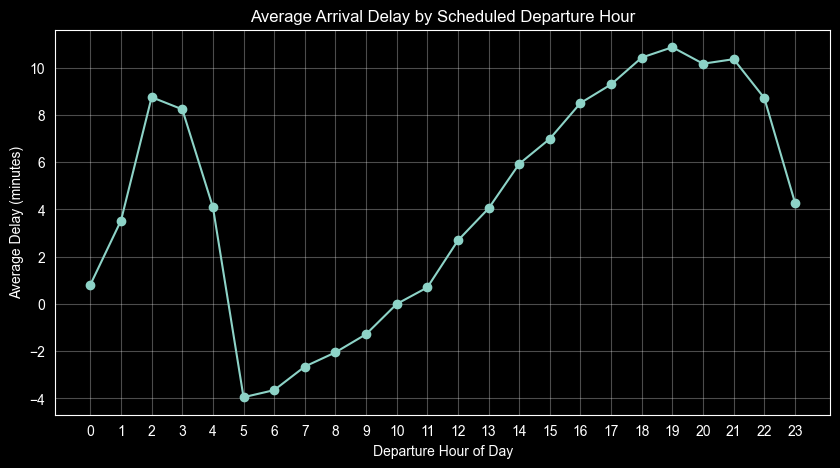

In [11]:
delay_by_hour = (
    df.groupby("dep_hour")["ArrDelay"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(delay_by_hour.index, delay_by_hour.values, marker="o")

plt.title("Average Arrival Delay by Scheduled Departure Hour")
plt.xlabel("Departure Hour of Day")
plt.ylabel("Average Delay (minutes)")

plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)

plt.show()

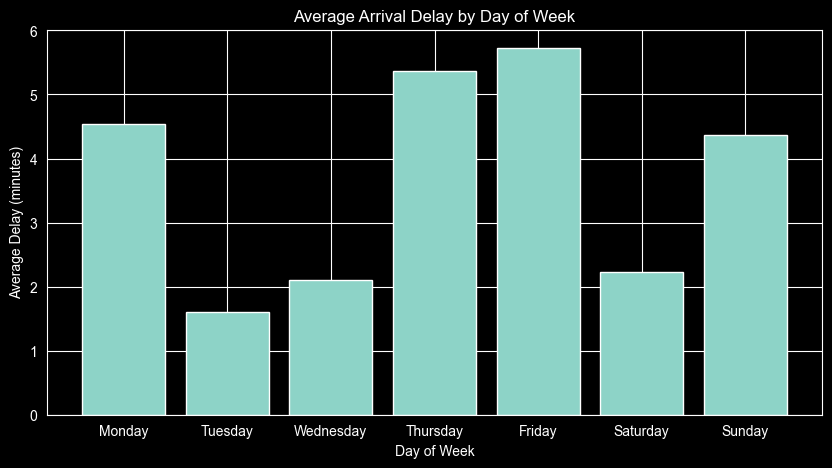

In [12]:
delay_by_day = (
    df.groupby("day_of_week")["ArrDelay"]
    .mean()
)

day_labels = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

plt.bar(day_labels, delay_by_day.values)

plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (minutes)")

plt.show()

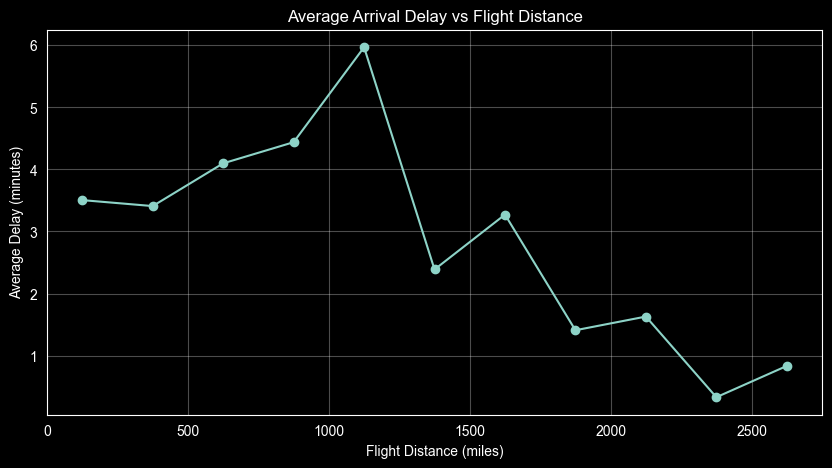

In [15]:
delay_by_distance = (
    df.groupby("DistanceGroup")["ArrDelay"]
    .mean()
    .sort_index()
)

# convert groups to midpoint miles
distance_midpoints = delay_by_distance.index * 250 - 125

plt.figure(figsize=(10,5))

plt.plot(distance_midpoints, delay_by_distance.values, marker="o")

plt.title("Average Arrival Delay vs Flight Distance")
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Average Delay (minutes)")

plt.grid(True, alpha=0.3)

plt.show()

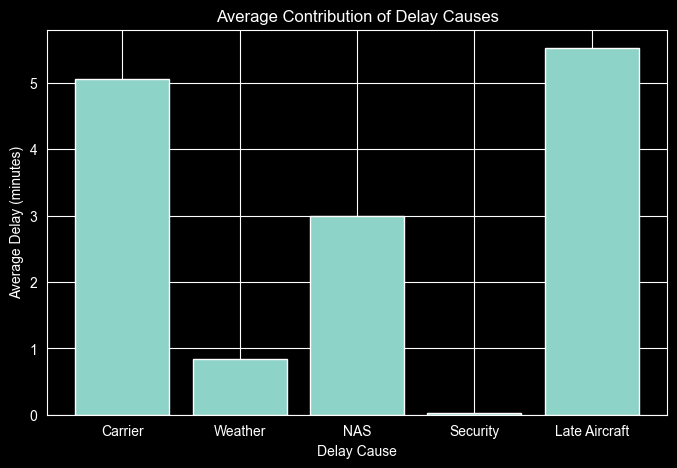

In [16]:
delay_causes = {
    "Carrier": df["CarrierDelay"].mean(),
    "Weather": df["WeatherDelay"].mean(),
    "NAS": df["NASDelay"].mean(),
    "Security": df["SecurityDelay"].mean(),
    "Late Aircraft": df["LateAircraftDelay"].mean()
}

plt.figure(figsize=(8,5))

plt.bar(delay_causes.keys(), delay_causes.values())

plt.title("Average Contribution of Delay Causes")
plt.xlabel("Delay Cause")
plt.ylabel("Average Delay (minutes)")

plt.show()

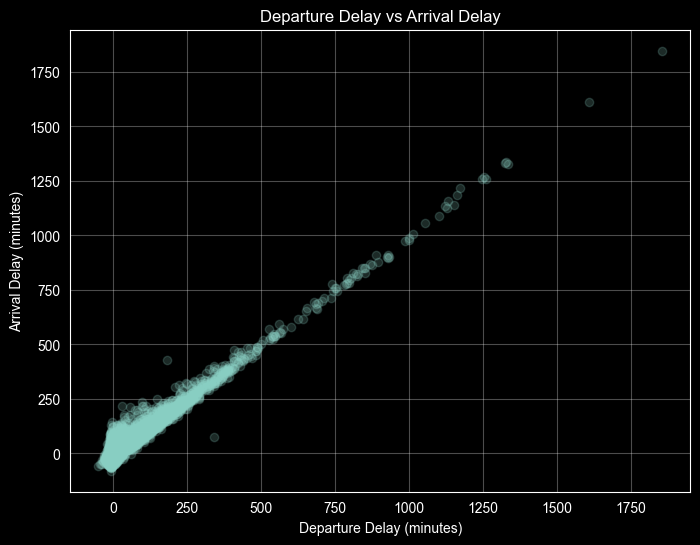

In [17]:
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(8,6))

plt.scatter(
    sample_df["DepDelay"],
    sample_df["ArrDelay"],
    alpha=0.2
)

plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.grid(True, alpha=0.3)

plt.show()

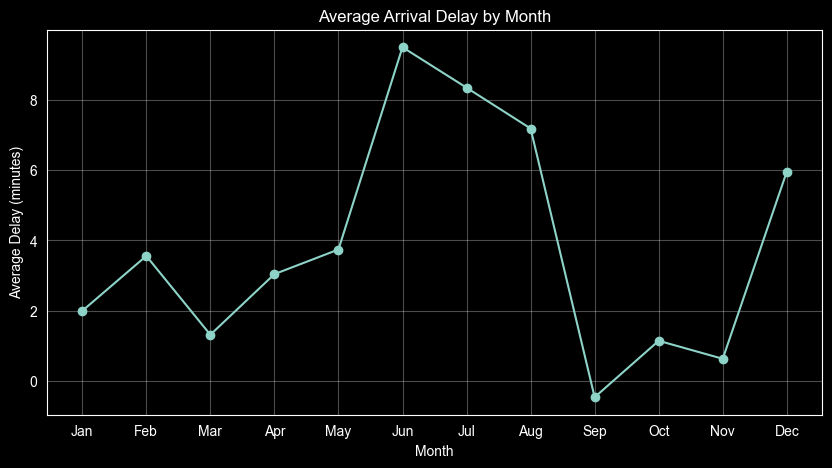

In [18]:
delay_by_month = (
    df.groupby("month")["ArrDelay"]
    .mean()
    .sort_index()
)

month_labels = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(10,5))

plt.plot(delay_by_month.index, delay_by_month.values, marker="o")

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.xticks(range(1,13), month_labels)
plt.grid(True, alpha=0.3)

plt.show()

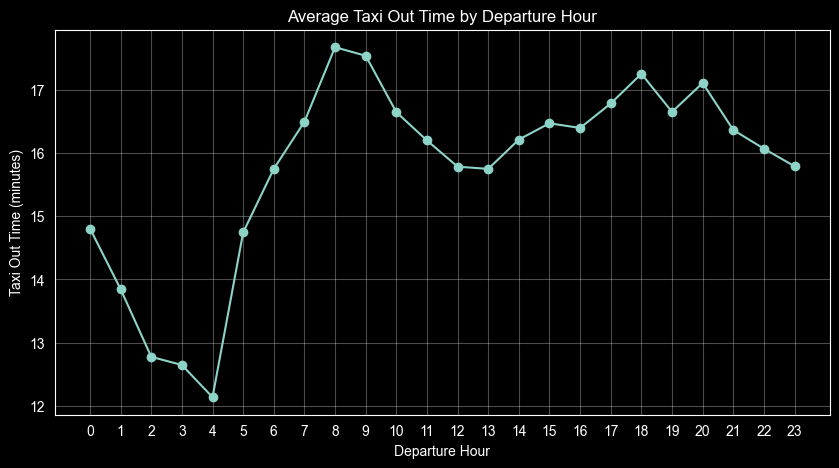

In [19]:
taxi_by_hour = df.groupby("dep_hour")["TaxiOut"].mean()

plt.figure(figsize=(10,5))

plt.plot(taxi_by_hour.index, taxi_by_hour.values, marker="o")

plt.title("Average Taxi Out Time by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Taxi Out Time (minutes)")

plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)

plt.show()

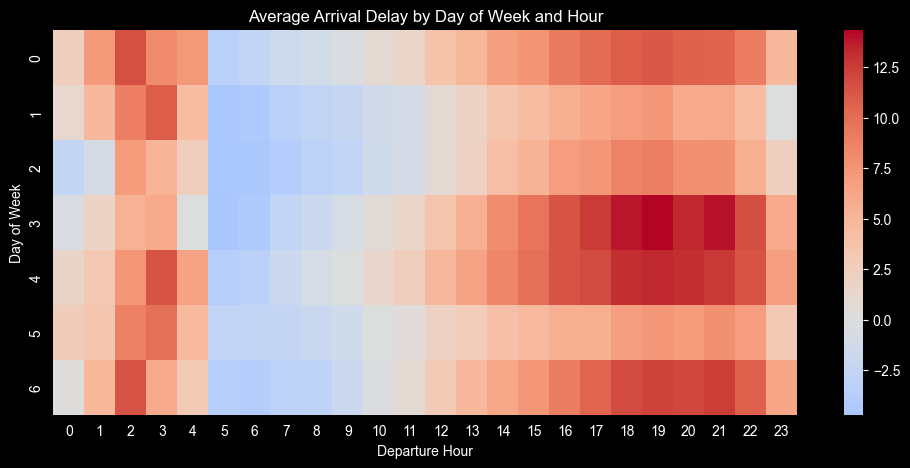

In [20]:
delay_heatmap = df.pivot_table(
    values="ArrDelay",
    index="day_of_week",
    columns="dep_hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,5))

sns.heatmap(delay_heatmap, cmap="coolwarm", center=0)

plt.title("Average Arrival Delay by Day of Week and Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Day of Week")

plt.show()

In [21]:
df["dep_delay_ratio"] = df["DepDelay"] / (df["CRSElapsedTime"] + 1)

df["delay_recovered"] = df["DepDelay"] - df["ArrDelay"]

df["is_late_departure"] = (df["DepDelay"] > 15).astype(int)

In [22]:
df["taxi_total"] = df["TaxiOut"] + df["TaxiIn"]

df["taxi_ratio"] = df["TaxiOut"] / (df["TaxiIn"] + 1)

In [23]:
df["total_reported_delay"] = (
    df["CarrierDelay"] +
    df["WeatherDelay"] +
    df["NASDelay"] +
    df["SecurityDelay"] +
    df["LateAircraftDelay"]
)

df["weather_delay_flag"] = (df["WeatherDelay"] > 0).astype(int)

In [24]:
df["route"] = df["OriginCityName"] + "_" + df["DestCityName"]

route_frequency = df["route"].value_counts()

df["route_frequency"] = df["route"].map(route_frequency)

In [25]:
df["hour_sin"] = np.sin(2 * np.pi * df["dep_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["dep_hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [26]:
df["is_delay"] = (df["ArrDelay"] > 15).astype(int)

df["is_delay"].value_counts(normalize=True)

is_delay
0    0.792686
1    0.207314
Name: proportion, dtype: float64

In [27]:
drop_cols = [
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrTime",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

df_model = df.drop(columns=drop_cols)

In [28]:
features = [
    "dep_hour",
    "month",
    "day_of_week",
    "is_weekend",
    "Distance",
    "DistanceGroup",
    "TaxiOut",
    "CRSElapsedTime",
    "DepDelay",
    "dep_delay_ratio",
    "rush_hour",
    "route_frequency",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "airline_code"
]

X = df_model[features]
y = df_model["is_delay"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

/Users/daniloruberti/Desktop/FlightDelays2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.97      0.99      0.98   4777150
           1       0.95      0.87      0.91   1249385

    accuracy                           0.96   6026535
   macro avg       0.96      0.93      0.94   6026535
weighted avg       0.96      0.96      0.96   6026535



In [31]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)

print("ROC AUC:", auc)

ROC AUC: 0.9728021173278457


In [32]:
df_reg = df.copy()

y_reg = df_reg["ArrDelay"]

In [33]:
drop_cols = [
    "ArrDelayMinutes",
    "ArrTime",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
    "is_delay"
]

df_reg = df_reg.drop(columns=drop_cols)

In [38]:
features = [
    "dep_hour",
    "month",
    "day_of_week",
    "is_weekend",
    "Distance",
    "DistanceGroup",
    "CRSElapsedTime",
    "rush_hour",
    "route_frequency",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "airline_code"
]

X = df_reg[features]
y = y_reg

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 54.29622637808015
MAE: 26.685837661485586
R2: 0.009677467623098845


In [42]:
df_delay_only = df[df["ArrDelay"] > 15].copy()

X = df_delay_only[features]
y = df_delay_only["ArrDelay"]

In [43]:
y = y.clip(-30, 180)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 46.739697305939394
MAE: 36.58670355632382
R2: 0.03171513341674148


In [47]:
origin_delay = df.groupby("OriginCityName")["ArrDelay"].mean()

df["origin_avg_delay"] = df["OriginCityName"].map(origin_delay)

In [48]:
dest_delay = df.groupby("DestCityName")["ArrDelay"].mean()

df["dest_avg_delay"] = df["DestCityName"].map(dest_delay)

In [49]:
airline_avg_delay = df.groupby("Marketing_Airline_Network")["ArrDelay"].mean()

df["airline_avg_delay"] = df["Marketing_Airline_Network"].map(airline_avg_delay)

In [50]:
route_avg_delay = df.groupby("route")["ArrDelay"].mean()

df["route_avg_delay"] = df["route"].map(route_avg_delay)

In [51]:
origin_traffic = df["OriginCityName"].value_counts()

df["origin_traffic"] = df["OriginCityName"].map(origin_traffic)

In [52]:
dest_traffic = df["DestCityName"].value_counts()

df["dest_traffic"] = df["DestCityName"].map(dest_traffic)

In [53]:
df["is_summer_peak"] = df["month"].isin([6,7,8]).astype(int)
df["is_holiday_season"] = df["month"].isin([11,12]).astype(int)

In [54]:
df["origin_hour"] = df["OriginCityName"] + "_" + df["dep_hour"].astype(str)

In [55]:
df_delay_only = df[df["ArrDelay"] > 15].copy()

y = df_delay_only["ArrDelay"].clip(-30, 180)

In [56]:
features = [
    "dep_hour",
    "month",
    "day_of_week",
    "is_weekend",
    "Distance",
    "DistanceGroup",
    "CRSElapsedTime",
    "rush_hour",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "airline_code",
    "route_frequency",

    # new engineered variables
    "origin_avg_delay",
    "dest_avg_delay",
    "airline_avg_delay",
    "route_avg_delay",
    "origin_traffic",
    "dest_traffic"
]

X = df_delay_only[features]

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 46.51918349719025
MAE: 36.37682198607515
R2: 0.04083014747867708


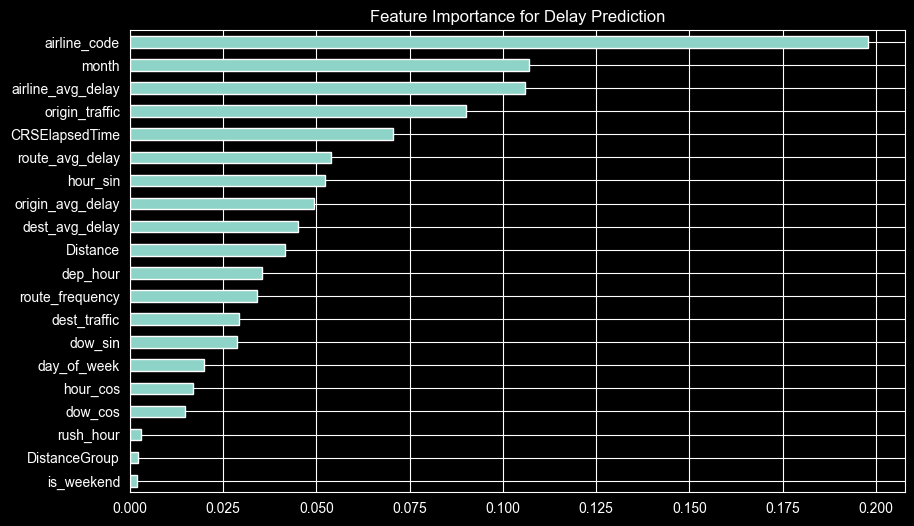

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=features)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance for Delay Prediction")
plt.show()

In [61]:
df.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,OriginCityName,DestCityName,CRSDepTime,DepTime,DepDelay,...,is_delay,origin_avg_delay,dest_avg_delay,airline_avg_delay,route_avg_delay,origin_traffic,dest_traffic,is_summer_peak,is_holiday_season,origin_hour
1,2018,1,15,2018-01-15,UA,"Newark, NJ","Charleston, SC",1845,1928.0,43.0,...,1,9.649161,3.883541,5.938247,9.379456,576284,102766,0,0,"Newark, NJ_18"
2,2018,1,16,2018-01-16,UA,"Newark, NJ","Charleston, SC",1835,1956.0,81.0,...,1,9.649161,3.883541,5.938247,9.379456,576284,102766,0,0,"Newark, NJ_18"
3,2018,1,17,2018-01-17,UA,"Newark, NJ","Charleston, SC",1835,1836.0,1.0,...,0,9.649161,3.883541,5.938247,9.379456,576284,102766,0,0,"Newark, NJ_18"
4,2018,1,18,2018-01-18,UA,"Newark, NJ","Charleston, SC",1845,1844.0,-1.0,...,0,9.649161,3.883541,5.938247,9.379456,576284,102766,0,0,"Newark, NJ_18"
6,2018,1,20,2018-01-20,UA,"Newark, NJ","Charleston, SC",1835,1829.0,-6.0,...,0,9.649161,3.883541,5.938247,9.379456,576284,102766,0,0,"Newark, NJ_18"
